In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/car_prediction_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Dataset Shape:
(301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission    

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [5]:
print("Fuel Types:")
print(df['Fuel_Type'].value_counts())

print("\nSeller Types:")
print(df['Seller_Type'].value_counts())

print("\nTransmission Types:")
print(df['Transmission'].value_counts())

print("\nOwner Types:")
print(df['Owner'].value_counts())

Fuel Types:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Seller Types:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission Types:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner Types:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


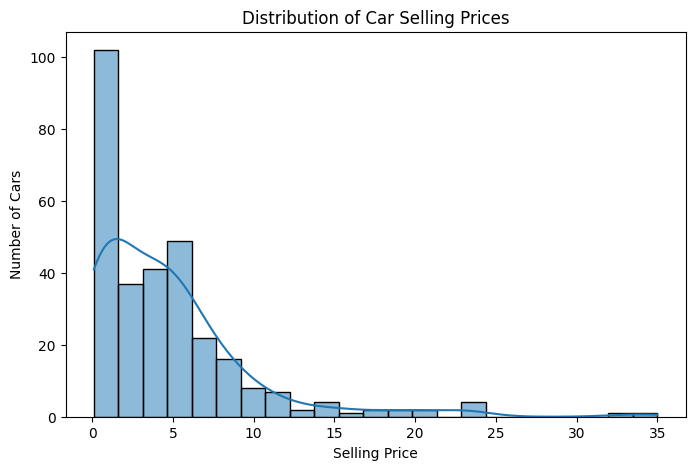

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

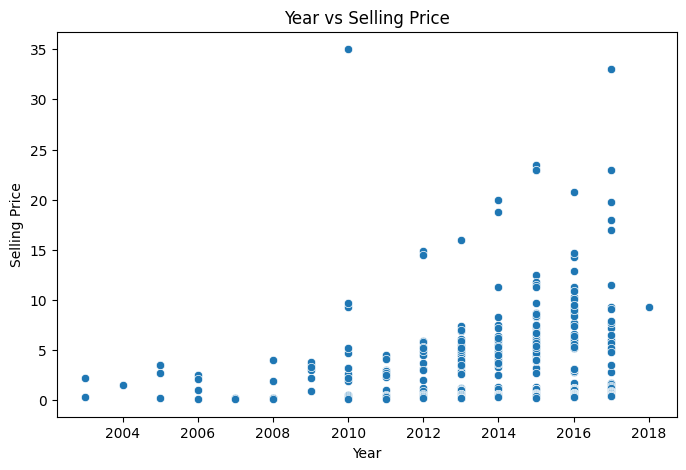

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Year',
    y='Selling_Price',
    data=df
)

plt.title('Year vs Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')

plt.show()

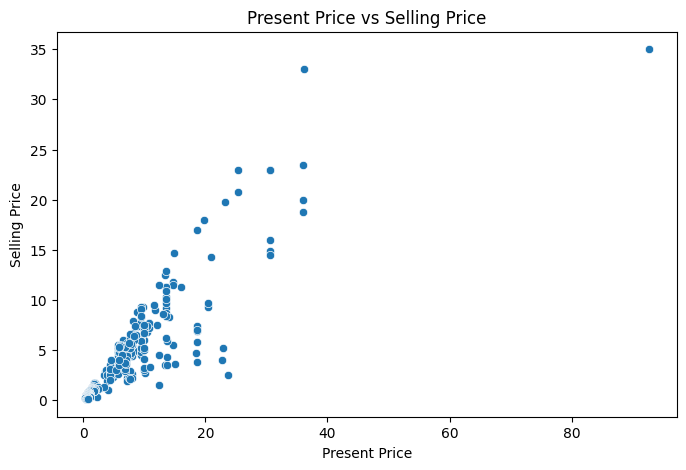

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')

plt.show()

In [9]:
df_encoded = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Seller_Type', 'Transmission'],
    drop_first=True
)

df_encoded.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,True,False,False,True


In [10]:
print(df_encoded['Owner'].value_counts())

Owner
0    290
1     10
3      1
Name: count, dtype: int64


In [11]:
X = df_encoded.drop(['Selling_Price', 'Car_Name'], axis=1)
y = df_encoded['Selling_Price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (301, 8)
Target shape: (301,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 8)
Testing data: (61, 8)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [14]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [15]:
print("Actual Prices:")
print(y_test.values[:10])

print("\nPredicted Prices:")
print(linear_pred[:10])

Actual Prices:
[ 0.35 10.11  4.95  0.15  6.95  7.45  1.1   0.5   0.45  6.  ]

Predicted Prices:
[ 2.95534303  8.178939    6.45427257 -1.42417501  9.08889914  7.41825441
  1.33644285  0.84027217  1.36501949  7.49026806]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
MAE: 1.2162256821297057
RMSE: 1.8651552135513827
R2 Score: 0.8489813024899066


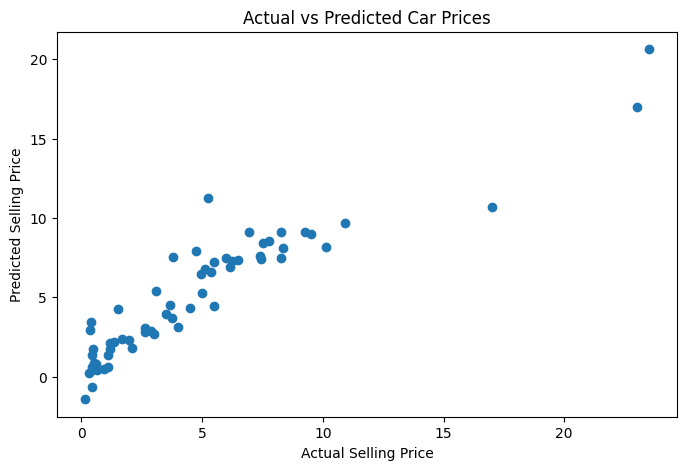

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, linear_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [19]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 0.587265573770492
RMSE: 0.8825421585620394
R2 Score: 0.9661879358453749


In [20]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R2 Score': [linear_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.216226,1.865155,0.848981
1,Random Forest,0.587266,0.882542,0.966188


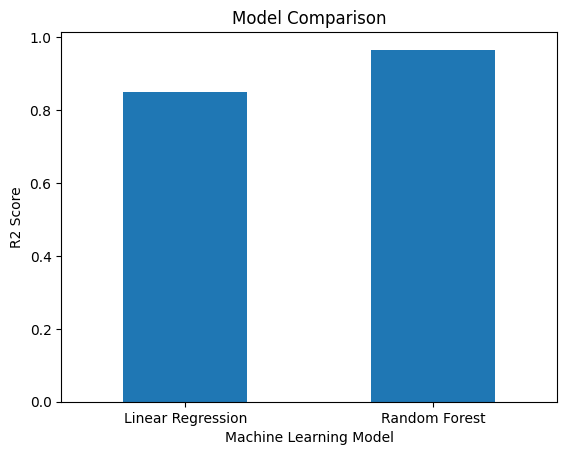

In [21]:
comparison.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    legend=False
)

plt.title('Model Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=0)

plt.show()

In [22]:
print(comparison)

print("\nLinear Regression R2:", round(linear_r2, 4))
print("Random Forest R2:", round(rf_r2, 4))

               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.216226  1.865155  0.848981
1      Random Forest  0.587266  0.882542  0.966188

Linear Regression R2: 0.849
Random Forest R2: 0.9662


In [23]:
if rf_r2 > linear_r2:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_r2 = rf_r2
else:
    best_model = linear_model
    best_model_name = "Linear Regression"
    best_r2 = linear_r2

print("Best Model:", best_model_name)
print("Best R2 Score:", round(best_r2, 4))

Best Model: Random Forest
Best R2 Score: 0.9662


In [24]:
sample_car = X_test.iloc[[0]]

predicted_price = best_model.predict(sample_car)[0]

print("Predicted Selling Price:", round(predicted_price, 2))

Predicted Selling Price: 0.44


In [25]:
actual_price = y_test.iloc[0]

print("Actual Selling Price:", round(actual_price, 2))
print("Predicted Selling Price:", round(predicted_price, 2))

Actual Selling Price: 0.35
Predicted Selling Price: 0.44


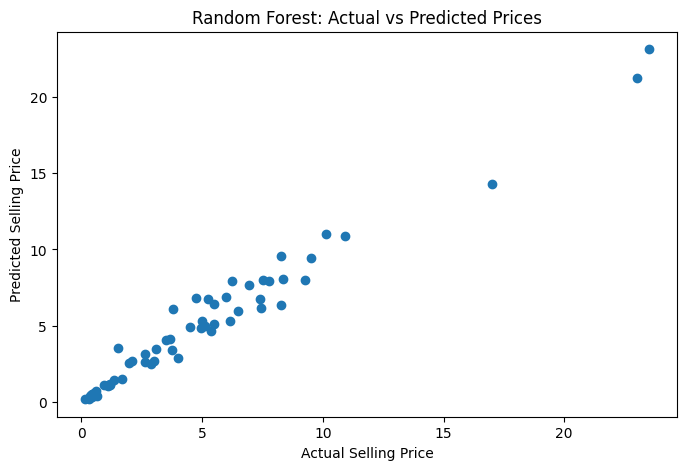

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted Prices")

plt.show()

In [27]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                  Feature  Importance
1           Present_Price    0.879915
0                    Year    0.063523
2              Kms_Driven    0.034716
7     Transmission_Manual    0.010999
5        Fuel_Type_Petrol    0.004826
6  Seller_Type_Individual    0.002479
4        Fuel_Type_Diesel    0.001827
3                   Owner    0.001715


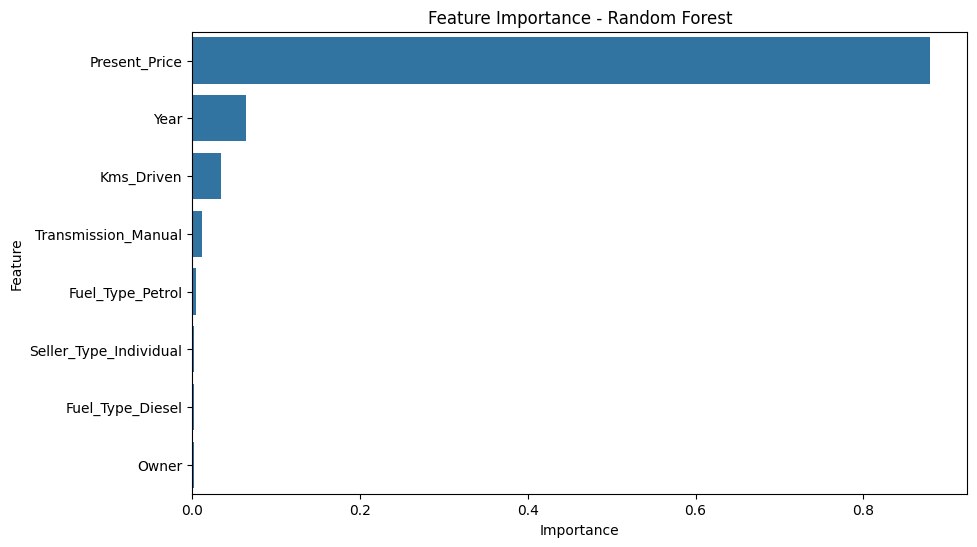

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Project Summary

This project focuses on predicting car selling prices using machine learning.

The dataset was cleaned and explored using Python. Categorical features were converted into numerical form using one-hot encoding. The data was divided into training and testing sets.

Two machine learning models were trained:
- Linear Regression
- Random Forest Regressor

The models were evaluated using MAE, RMSE, and R² Score. Random Forest achieved an R² Score of 0.9662, making it the selected model for this project.

The model was also used to predict the selling price of a sample car.

## Conclusion

In this project, a machine learning model was developed to predict car selling prices.

The dataset was analyzed, cleaned, and prepared for machine learning. Different features related to cars were used to train the models.

Linear Regression and Random Forest Regressor were compared using evaluation metrics. Random Forest achieved an R² Score of 0.9662, showing a strong fit on the test data.

This project helped in understanding the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, prediction, and evaluation.